# EGFR Virtual Biopsy — Additional Figures (No Retraining)

Builds **7 more figures** for the paper, using only things that already exist on disk — **no model
is trained in this notebook**:

- `figures_out/raw_data/oof_predictions.csv` and `fold_results.json` — saved by the previous
  figure-generation run.
- `egfr_out/egfr_fusion_v32.pt` — your saved FULL model checkpoint, loaded once for a
  forward-pass-only inference (no gradient updates, no training loop).
- `egfr_cache/`, `egfr_out/radiomics_*.csv` — same caches as before, reused as-is.

Sections 1–9 below are copied verbatim from `EGFR_Multimodal_Training_v3_2.ipynb` (same as the
previous figure notebook) purely to rebuild `cohort`, `tab_mat`, `rad_mat_raw`, and the model class
definitions in memory — this reuses your caches and takes a few minutes, not the hours a full
training run took. **Section 13 onward is new** and only ever does inference or instant classical-ML
fits (logistic regression, PCA), never deep-learning training.

**New figures:**
1. Precision-Recall curves (more informative than ROC given 23.7% prevalence)
2. Predicted-probability distributions by true class (clinical-only vs. FULL)
3. Per-site (AMC vs. R01) performance breakdown — *not* external validation, clearly caveated
4. Clinical-only vs. FULL prediction correlation scatter — tests the paper's "overlapping signal" claim directly
5. Top clinical feature importances (instant logistic regression fit, not the CV models)
6. Top radiomics feature importances (same)
7. PCA of the FULL model's learned fused embeddings, colored by true label — loads the saved
   checkpoint for inference only

**Run this in the same folder as before** (`D:\git\PhDProjects\LungCancerGrading`), after the
first figure-generation notebook has already been run once (so `figures_out/raw_data/` exists).


## 1. Install (run once)

In [1]:
import sys
# !{sys.executable} -m pip install -q "pydicom<3" pydicom-seg SimpleITK scipy scikit-learn scikit-image matplotlib tqdm torchvision
print("done")
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

done


## 2. Imports

In [2]:
import os, glob, shutil, random, warnings, math, numpy as np, pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import pydicom, pydicom_seg, SimpleITK as sitk
from scipy import ndimage
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x
warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch", torch.__version__, "| Device:", DEVICE)
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score


d:\git\PhDProjects\LungCancerGrading\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch 2.12.1+cu126 | Device: cpu


## 3. CONFIG

In [3]:
DATA_ROOT    = Path("data/nsclc_radiogenomics")
CLINICAL_CSV = Path("data/NSCLCR01Radiogenomic_DATA_LABELS_2018-05-22_1500-shifted.csv")
AIM_DIR      = Path("data/AIM_files_updated-11-10-2020/AIM_files_updated-11-10-2020")
CACHE_BASE   = Path("egfr_cache")
OUTPUT_DIR   = Path("egfr_out"); OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_COL, POS_LABEL, NEG_LABEL = "EGFR mutation status", "Mutant", "Wildtype"

TARGET_SHAPE   = (32, 64, 64); CROP_PAD_VOX = 16
HU_MIN, HU_MAX = -1000, 400
REQUIRE_SEG    = False
USE_AIM_COORD_FALLBACK = True
ALLOW_CENTER_CROP_FALLBACK = False
AIM_DEPTH_SLICES = TARGET_SHAPE[0]
FORCE_REBUILD  = False

INCLUDE_HISTOLOGY = False
INCLUDE_ETHNICITY = True

IMAGE_BACKBONE = "2.5d"            # keep 2.5d (best/most stable image branch)
PRETRAINED     = True
IMG_FEAT_DIM   = 64; TAB_HIDDEN = 64; FUSION_HIDDEN = 64; DROPOUT = 0.4
FREEZE_SLICE_BACKBONE=True; VIT_D_MODEL=192; VIT_HEADS=3; VIT_LAYERS=2; VIT_FF=384; SLICE_RES=224

N_FOLDS = 5; N_REPEATS = 5; EPOCHS = 60; LR = 1e-4; WEIGHT_DECAY = 1e-4
BATCH_SIZE = 8; USE_AUGMENTATION = True; USE_CLASS_WEIGHTS = True; SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

PRE_TAG = f"seg{int(REQUIRE_SEG)}_aim{int(USE_AIM_COORD_FALLBACK)}_{TARGET_SHAPE[0]}x{TARGET_SHAPE[1]}x{TARGET_SHAPE[2]}_pad{CROP_PAD_VOX}"
CACHE_DIR = CACHE_BASE / PRE_TAG
if FORCE_REBUILD and CACHE_DIR.exists(): shutil.rmtree(CACHE_DIR)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("cache:", CACHE_DIR)

FIG_DIR = Path("figures_out"); FIG_DIR.mkdir(exist_ok=True)
RAW_DIR = FIG_DIR / "raw_data"
assert RAW_DIR.exists(), ("raw_data/ not found - run EGFR_Figure_Generation.ipynb first, "
                          "it saves the files this notebook loads.")
print("Reading saved raw data from:", RAW_DIR.resolve())
print("Figures will be (re)saved to:", FIG_DIR.resolve())


cache: egfr_cache\seg0_aim1_32x64x64_pad16
Reading saved raw data from: D:\git\PhDProjects\LungCancerGrading\figures_out\raw_data
Figures will be (re)saved to: D:\git\PhDProjects\LungCancerGrading\figures_out


## 4. Clinical labels + tabular features

In [4]:
clin = pd.read_csv(CLINICAL_CSV)
clin["Case ID"] = clin["Case ID"].astype(str).str.strip()
clin["label"] = clin[TARGET_COL].map({POS_LABEL: 1, NEG_LABEL: 0})
clin = clin.dropna(subset=["label"]).copy(); clin["label"] = clin["label"].astype(int)
print("Usable EGFR labels:", len(clin)); print(clin["label"].value_counts().rename({0:NEG_LABEL,1:POS_LABEL}))

def build_tabular(df):
    f = pd.DataFrame(index=df.index)
    age = pd.to_numeric(df["Age at Histological Diagnosis"], errors="coerce")
    f["age"] = age.fillna(age.median())/100.0
    f["male"] = (df["Gender"].astype(str).str.strip().str.lower()=="male").astype(float)
    sm = df["Smoking status"].astype(str).str.strip()
    for v in ["Nonsmoker","Former","Current"]: f[f"smk_{v}"] = (sm==v).astype(float)
    for c in [c for c in df.columns if c.startswith("Tumor Location")]:
        key = c.split("choice=")[-1].rstrip(")").strip().replace(" ","_")
        f[f"loc_{key}"] = (df[c].astype(str).str.strip().str.lower()=="checked").astype(float)
    f = pd.concat([f, pd.get_dummies(df["%GG"].astype(str).str.strip(), prefix="gg").astype(float)], axis=1)
    if INCLUDE_ETHNICITY and "Ethnicity" in df.columns:
        f = pd.concat([f, pd.get_dummies(df["Ethnicity"].astype(str).str.strip(), prefix="eth").astype(float)], axis=1)
    if INCLUDE_HISTOLOGY:
        f = pd.concat([f, pd.get_dummies(df["Histology "].astype(str).str.strip(), prefix="hist").astype(float)], axis=1)
    return f
print("Tabular features:", build_tabular(clin).shape[1])

Usable EGFR labels: 172
label
Wildtype    129
Mutant       43
Name: count, dtype: int64
Tabular features: 25


## 5. Index DICOM + match AIM files

In [5]:
ALL_AIM = glob.glob(os.path.join(str(AIM_DIR), "*.xml")) if AIM_DIR.exists() else []
def aim_file_for(cid):
    mf = [f for f in ALL_AIM if cid in os.path.basename(f)]
    return mf[0] if mf else None

def scan_patient(pdir):
    info = {"ct_dir": None, "ct_n": 0, "seg_file": None, "seg_modality": None}
    for root, _, files in os.walk(pdir):
        dcms = [f for f in files if f.lower().endswith(".dcm")]
        if not dcms: continue
        try: ds = pydicom.dcmread(os.path.join(root, dcms[0]), stop_before_pixels=True, force=True)
        except Exception: continue
        mod = str(getattr(ds, "Modality", "")).upper()
        if mod == "CT":
            if len(dcms) > info["ct_n"]: info["ct_dir"], info["ct_n"] = root, len(dcms)
        elif mod in ("SEG","RTSTRUCT"):
            info["seg_file"], info["seg_modality"] = os.path.join(root, dcms[0]), mod
    return info

records = []
for cid in tqdm(clin["Case ID"].tolist(), desc="indexing"):
    pdir = DATA_ROOT/cid
    info = scan_patient(pdir) if pdir.exists() else {"ct_dir":None,"ct_n":0,"seg_file":None,"seg_modality":None}
    info["Case ID"] = cid; info["aim_file"] = aim_file_for(cid); records.append(info)
cohort = clin.merge(pd.DataFrame(records), on="Case ID", how="left")
print("CT:", cohort["ct_dir"].notna().sum(), "| SEG:", (cohort["seg_modality"]=="SEG").sum(),
      "| AIM:", cohort["aim_file"].notna().sum())

indexing: 100%|██████████| 172/172 [00:15<00:00, 10.88it/s]

CT: 172 | SEG: 117 | AIM: 158


## 6. AIM markup parser + coordinate cropper

In [6]:
def _local(t): return t.rsplit('}',1)[-1]
def parse_aim_markup(xml_path):
    out=[]
    try: root=ET.parse(xml_path).getroot()
    except Exception: return out
    for me in root.iter():
        if _local(me.tag)!="MarkupEntity": continue
        sop=None;frame=None;pts=[]
        for el in me.iter():
            lt=_local(el.tag)
            if lt=="imageReferenceUid": sop=el.get("root")
            elif lt=="referencedFrameNumber": frame=el.get("value")
            elif lt=="TwoDimensionSpatialCoordinate":
                x=y=None
                for c in el:
                    if _local(c.tag)=="x": x=float(c.get("value"))
                    if _local(c.tag)=="y": y=float(c.get("value"))
                if x is not None and y is not None: pts.append((x,y))
        if pts: out.append({"sop":sop,"frame":frame,"xy":pts})
    return out

def sop_to_zindex(ct_dir):
    files=sitk.ImageSeriesReader().GetGDCMSeriesFileNames(str(ct_dir)); m={}
    for i,fp in enumerate(files):
        try:
            ds=pydicom.dcmread(fp,stop_before_pixels=True,force=True); m[str(getattr(ds,'SOPInstanceUID',''))]=i
        except Exception: pass
    return m

def _finish_cube(crop):
    if crop.size==0 or min(crop.shape)<2: return None
    crop=ndimage.zoom(crop.astype(np.float32),[t/max(1,s) for t,s in zip(TARGET_SHAPE,crop.shape)],order=1)
    crop=np.clip(crop,HU_MIN,HU_MAX)
    return ((crop-HU_MIN)/(HU_MAX-HU_MIN)).astype(np.float32)

def crop_from_aim(ct_arr, sop_map, markups):
    Z,Y,X=ct_arr.shape
    for mk in markups:
        if mk["sop"] not in sop_map: continue
        z=sop_map[mk["sop"]]; pts=mk["xy"]; cx,cy=pts[0]
        r=math.hypot(pts[1][0]-cx,pts[1][1]-cy) if len(pts)>=2 else 25.0
        r=max(r,10.0); half=int(round(r))+CROP_PAD_VOX; dz=AIM_DEPTH_SLICES//2
        y0,y1=max(0,int(cy)-half),min(Y,int(cy)+half); x0,x1=max(0,int(cx)-half),min(X,int(cx)+half)
        z0,z1=max(0,z-dz),min(Z,z+dz)
        cube=_finish_cube(ct_arr[z0:z1,y0:y1,x0:x1])
        if cube is not None: return cube,"ok"
    return None,"no_resolvable_markup"

## 7. Preprocess -> tumour cubes (SEG first, AIM fallback)

In [7]:
def load_ct(ct_dir):
    r=sitk.ImageSeriesReader(); r.SetFileNames(r.GetGDCMSeriesFileNames(str(ct_dir))); return r.Execute()
def seg_mask_on_ct(seg_file, ct_img):
    result=pydicom_seg.SegmentReader().read(pydicom.dcmread(seg_file)); mask=None
    for num in result.available_segments:
        res=sitk.Resample(result.segment_image(num),ct_img,sitk.Transform(),sitk.sitkNearestNeighbor,0,sitk.sitkUInt8)
        a=sitk.GetArrayFromImage(res).astype(bool); mask=a if mask is None else (mask|a)
    return mask
def crop_to_cube(ct_arr, mask):
    if mask is not None and mask.any():
        zz,yy,xx=np.where(mask); p=CROP_PAD_VOX
        z0,z1=max(0,zz.min()-p),min(ct_arr.shape[0],zz.max()+p+1)
        y0,y1=max(0,yy.min()-p),min(ct_arr.shape[1],yy.max()+p+1)
        x0,x1=max(0,xx.min()-p),min(ct_arr.shape[2],xx.max()+p+1)
    else:
        Z,Y,X=ct_arr.shape; z0,z1=int(Z*.25),int(Z*.75);y0,y1=int(Y*.2),int(Y*.8);x0,x1=int(X*.2),int(X*.8)
    return _finish_cube(ct_arr[z0:z1,y0:y1,x0:x1])

status=[]
for _,row in tqdm(cohort.iterrows(), total=len(cohort), desc="preprocess"):
    cid=row["Case ID"]; out=CACHE_DIR/f"{cid}.npy"
    if out.exists(): status.append((cid,"cached")); continue
    if pd.isna(row["ct_dir"]): status.append((cid,"no_ct")); continue
    try:
        ct=load_ct(row["ct_dir"]); ct_arr=sitk.GetArrayFromImage(ct); mask=None
        if row["seg_modality"]=="SEG":
            try: mask=seg_mask_on_ct(row["seg_file"],ct)
            except Exception: mask=None
        if mask is not None and mask.any():
            cube=crop_to_cube(ct_arr,mask)
            if cube is not None: np.save(out,cube); status.append((cid,"ok_seg")); continue
        if USE_AIM_COORD_FALLBACK and isinstance(row["aim_file"],str):
            markups=parse_aim_markup(row["aim_file"])
            if markups:
                cube,_=crop_from_aim(ct_arr,sop_to_zindex(row["ct_dir"]),markups)
                if cube is not None: np.save(out,cube); status.append((cid,"ok_aim")); continue
                status.append((cid,"aim_unresolved")); continue
            status.append((cid,"aim_no_markup")); continue
        if ALLOW_CENTER_CROP_FALLBACK and not REQUIRE_SEG:
            cube=crop_to_cube(ct_arr,None)
            if cube is not None: np.save(out,cube); status.append((cid,"ok_centercrop")); continue
        status.append((cid,"no_seg_skipped"))
    except Exception as e: status.append((cid,f"error:{type(e).__name__}"))

st=pd.DataFrame(status,columns=["Case ID","status"]); print(st["status"].value_counts())
cohort=cohort.merge(st,on="Case ID",how="left")
cohort=cohort[cohort["status"].isin(["ok_seg","ok_aim","ok_centercrop","cached"])].reset_index(drop=True)
print("\nFinal cohort:",len(cohort)); print(cohort["label"].value_counts().rename({0:NEG_LABEL,1:POS_LABEL}))

preprocess: 100%|██████████| 172/172 [02:38<00:00,  1.08it/s]

status
cached            139
aim_unresolved     20
no_seg_skipped     13
Name: count, dtype: int64

Final cohort: 139
label
Wildtype    106
Mutant       33
Name: count, dtype: int64


## 8. Radiomics features (first-order + shape + GLCM)

In [8]:
def tumor_roi(cube, thr=0.5):
    m=cube>thr; D,H,W=cube.shape
    if not m.any():
        m=np.zeros_like(cube,bool); m[D//4:3*D//4,H//4:3*H//4,W//4:3*W//4]=True; return m
    lbl,n=ndimage.label(m); cl=lbl[D//2,H//2,W//2]
    if cl>0: return lbl==cl
    sizes=ndimage.sum(np.ones_like(lbl),lbl,index=range(1,n+1))
    return lbl==(1+int(np.argmax(sizes)))

def radiomics_features(cube):
    f={}; roi=tumor_roi(cube); vals=cube[roi]
    if vals.size<8: vals=cube.ravel()
    f["fo_mean"]=vals.mean(); f["fo_std"]=vals.std(); f["fo_median"]=np.median(vals)
    f["fo_p10"]=np.percentile(vals,10); f["fo_p90"]=np.percentile(vals,90)
    f["fo_iqr"]=np.percentile(vals,75)-np.percentile(vals,25)
    f["fo_min"]=vals.min(); f["fo_max"]=vals.max(); f["fo_range"]=vals.max()-vals.min()
    f["fo_mad"]=np.mean(np.abs(vals-vals.mean())); f["fo_skew"]=skew(vals); f["fo_kurt"]=kurtosis(vals)
    f["fo_energy"]=np.mean(vals**2)
    cnt,_=np.histogram(vals,bins=32,range=(0,1)); p=cnt/max(1,cnt.sum()); pp=p[p>0]
    f["fo_entropy"]=-(pp*np.log2(pp)).sum(); f["fo_uniformity"]=(p**2).sum()
    vol=float(roi.sum()); f["sh_volume"]=vol; coords=np.argwhere(roi)
    if len(coords)>0:
        bb=coords.max(0)-coords.min(0)+1
        f["sh_extent"]=vol/float(np.prod(bb)); f["sh_elongation"]=float(bb.min()/max(1,bb.max()))
    else: f["sh_extent"]=0.0; f["sh_elongation"]=0.0
    er=ndimage.binary_erosion(roi); surf=float((roi&~er).sum())
    f["sh_surface"]=surf; f["sh_sa_vol"]=surf/max(1.0,vol)
    f["sh_sphericity"]=float((4*np.pi*((3*vol/(4*np.pi))**(2/3)))/max(1.0,surf)) if vol>0 else 0.0
    areas=roi.sum((1,2)); z=int(np.argmax(areas)) if areas.max()>0 else cube.shape[0]//2
    sl=cube[z]
    if roi[z].any():
        ys,xs=np.where(roi[z]); sl=sl[ys.min():ys.max()+1, xs.min():xs.max()+1]
    levels=16; q=np.clip((sl*(levels-1)).round(),0,levels-1).astype(np.uint8)
    props=["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]
    if min(q.shape)>=3:
        glcm=graycomatrix(q,distances=[1],angles=[0,np.pi/4,np.pi/2,3*np.pi/4],levels=levels,symmetric=True,normed=True)
        for pr in props: f[f"tex_{pr}"]=float(np.nan_to_num(graycoprops(glcm,pr).mean()))
    else:
        for pr in props: f[f"tex_{pr}"]=0.0
    return f

RAD_CACHE=OUTPUT_DIR/f"radiomics_{PRE_TAG}.csv"
if RAD_CACHE.exists():
    rad_df=pd.read_csv(RAD_CACHE).set_index("Case ID")
else:
    rows={}
    for cid in tqdm(cohort["Case ID"], desc="radiomics"):
        rows[cid]=radiomics_features(np.load(CACHE_DIR/f"{cid}.npy"))
    rad_df=pd.DataFrame.from_dict(rows,orient="index"); rad_df.index.name="Case ID"
    rad_df.reset_index().to_csv(RAD_CACHE,index=False)
rad_df=rad_df.reindex(cohort["Case ID"]).fillna(0.0)
rad_mat_raw=np.nan_to_num(rad_df.values.astype(np.float32))
N_RAD=rad_mat_raw.shape[1]
RAD_MAT=np.nan_to_num(StandardScaler().fit_transform(rad_mat_raw)).astype(np.float32)
print("Radiomics features:",N_RAD); print(list(rad_df.columns))

Radiomics features: 27
['fo_mean', 'fo_std', 'fo_median', 'fo_p10', 'fo_p90', 'fo_iqr', 'fo_min', 'fo_max', 'fo_range', 'fo_mad', 'fo_skew', 'fo_kurt', 'fo_energy', 'fo_entropy', 'fo_uniformity', 'sh_volume', 'sh_extent', 'sh_elongation', 'sh_surface', 'sh_sa_vol', 'sh_sphericity', 'tex_contrast', 'tex_dissimilarity', 'tex_homogeneity', 'tex_energy', 'tex_correlation', 'tex_ASM']


## 9. Tabular matrix + Dataset

In [9]:
tab_mat=build_tabular(cohort).values.astype(np.float32)
N_TAB=tab_mat.shape[1]; labels=cohort["label"].values.astype(np.float32)
print("Tabular dim:",N_TAB,"| Radiomics dim:",N_RAD,"| N:",len(cohort),"| positives:",int(labels.sum()))

def augment_cube(cube):
    if random.random()<0.5: cube=torch.flip(cube,dims=[2])
    if random.random()<0.5: cube=torch.flip(cube,dims=[3])
    cube=cube*random.uniform(0.9,1.1)+random.uniform(-0.05,0.05)
    return cube.clamp(0,1)

class EGFRDataset(Dataset):
    def __init__(self, indices, train=False):
        self.indices=list(indices); self.train=train
    def __len__(self): return len(self.indices)
    def __getitem__(self,k):
        i=self.indices[k]
        cube=np.load(CACHE_DIR/f"{cohort.iloc[i]['Case ID']}.npy")
        img=torch.from_numpy(cube).float().unsqueeze(0)
        if self.train and USE_AUGMENTATION: img=augment_cube(img)
        tab=torch.from_numpy(tab_mat[i]).float()
        rad=torch.from_numpy(RAD_MAT[i]).float()
        y=torch.tensor([labels[i]],dtype=torch.float32)
        return img,tab,rad,y

Tabular dim: 25 | Radiomics dim: 27 | N: 139 | positives: 33


## 10. Model — image (2.5D) + clinical MLP + radiomics MLP -> fusion

In [10]:
class Image25DEncoder(nn.Module):
    def __init__(self,out_dim=IMG_FEAT_DIM,pretrained=PRETRAINED,p=DROPOUT):
        super().__init__()
        net=tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT if pretrained else None)
        self.features=nn.Sequential(*list(net.children())[:-1])
        self.proj=nn.Sequential(nn.Flatten(),nn.Dropout(p),nn.Linear(512,out_dim),nn.ReLU(inplace=True))
        self.register_buffer("mean",torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std", torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
    def forward(self,cube):
        D=cube.shape[2]; idx=[D//4,D//2,(3*D)//4]
        x=cube[:,0][:,idx,:,:]; x=F.interpolate(x,size=(224,224),mode="bilinear",align_corners=False)
        x=(x-self.mean)/self.std; return self.proj(self.features(x))

class Image3DEncoder(nn.Module):
    def __init__(self,out_dim=IMG_FEAT_DIM,p=DROPOUT):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv3d(ci,co,3,padding=1),nn.BatchNorm3d(co),nn.ReLU(inplace=True),nn.MaxPool3d(2))
        self.net=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),nn.AdaptiveAvgPool3d(1),nn.Flatten())
        self.proj=nn.Sequential(nn.Dropout(p),nn.Linear(64,out_dim),nn.ReLU(inplace=True))
    def forward(self,x): return self.proj(self.net(x))

def make_image_encoder():
    if IMAGE_BACKBONE=="3d": return Image3DEncoder()
    return Image25DEncoder()

class MLPEncoder(nn.Module):
    def __init__(self,n_in,hidden=TAB_HIDDEN,out_dim=32,p=DROPOUT):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(n_in,hidden),nn.ReLU(inplace=True),nn.Dropout(p),
                               nn.Linear(hidden,out_dim),nn.ReLU(inplace=True))
    def forward(self,x): return self.net(x)

class FusionNet(nn.Module):
    def __init__(self,n_tab,n_rad,use_image=True,use_tabular=True,use_radiomics=False):
        super().__init__()
        self.use_image,self.use_tabular,self.use_radiomics=use_image,use_tabular,use_radiomics; dim=0
        if use_image: self.img=make_image_encoder(); dim+=IMG_FEAT_DIM
        if use_tabular: self.tab=MLPEncoder(n_tab); dim+=32
        if use_radiomics: self.rad=MLPEncoder(n_rad); dim+=32
        self.head=nn.Sequential(nn.Linear(dim,FUSION_HIDDEN),nn.ReLU(inplace=True),
                                nn.Dropout(DROPOUT),nn.Linear(FUSION_HIDDEN,1))
    def forward(self,img,tab,rad):
        f=[]
        if self.use_image: f.append(self.img(img))
        if self.use_tabular: f.append(self.tab(tab))
        if self.use_radiomics: f.append(self.rad(rad))
        return self.head(torch.cat(f,1))

_m=FusionNet(N_TAB,N_RAD,True,True,True)
print("FULL model trainable params:",sum(p.numel() for p in _m.parameters() if p.requires_grad)); del _m

FULL model trainable params: 11225281


## 11. Load the previously saved OOF predictions and fold results

No computation here — just reading back what `EGFR_Figure_Generation.ipynb` already saved.


In [11]:
oof_df = pd.read_csv(RAW_DIR / "oof_predictions.csv")
with open(RAW_DIR / "fold_results.json") as f:
    fold_results = json.load(f)

print(f"Loaded OOF predictions for {len(oof_df)} patients.")
print("Columns:", list(oof_df.columns))
print("\nSite counts:")
print(oof_df["site"].value_counts())

y = oof_df["label"].values.astype(int)


Loaded OOF predictions for 139 patients.
Columns: ['Case ID', 'site', 'label', 'clinical_logreg', 'radiomics_logreg', 'clinical_radiomics_logreg', 'clinical_deep', 'image_deep', 'image_clinical_fusion', 'full_deep']

Site counts:
site
VA          71
Stanford    68
Name: count, dtype: int64


## 12. Figure E1 — Precision-Recall curves

With 23.7% mutant prevalence, precision-recall curves are more informative than ROC curves about
how a model performs on the minority (mutant) class specifically. The dashed horizontal line marks
the no-skill baseline (= class prevalence).


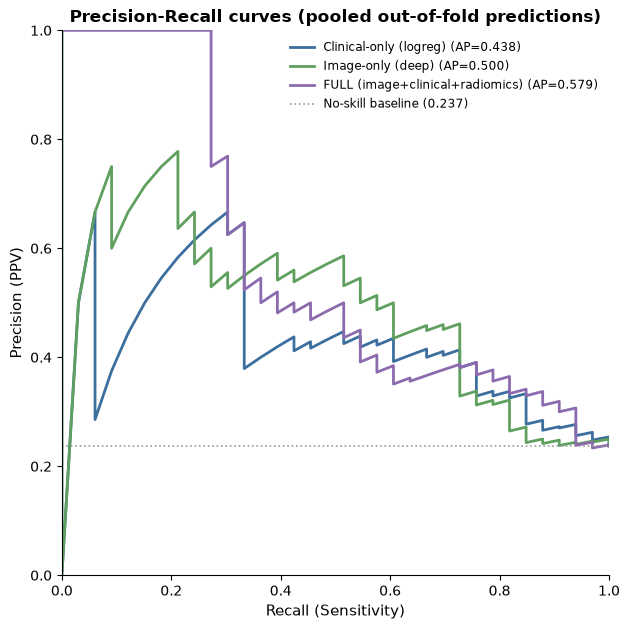

Saved -> figE1_precision_recall.png


In [12]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))
pr_models = [
    ("Clinical-only (logreg)", "clinical_logreg", "#3C6E9E"),
    ("Image-only (deep)",      "image_deep",      "#5FA05F"),
    ("FULL (image+clinical+radiomics)", "full_deep", "#8B6BAE"),
]
for name, col, color in pr_models:
    prec, rec, _ = precision_recall_curve(y, oof_df[col].values)
    ap = average_precision_score(y, oof_df[col].values)
    ax.plot(rec, prec, color=color, linewidth=2, label=f"{name} (AP={ap:.3f})")

prevalence = y.mean()
ax.axhline(prevalence, color="#999999", linestyle=":", linewidth=1.2, label=f"No-skill baseline ({prevalence:.3f})")
ax.set_xlabel("Recall (Sensitivity)", fontsize=10.5)
ax.set_ylabel("Precision (PPV)", fontsize=10.5)
ax.set_title("Precision-Recall curves (pooled out-of-fold predictions)", fontsize=12, weight="bold")
ax.legend(loc="upper right", fontsize=8.5, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "figE1_precision_recall.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> figE1_precision_recall.png")


## 13. Figure E2 — Predicted-probability distributions by true class

Shows the actual spread of predicted probabilities for Wildtype vs. Mutant patients, for
clinical-only and FULL side by side — a more granular view of discrimination than a single AUROC
number.


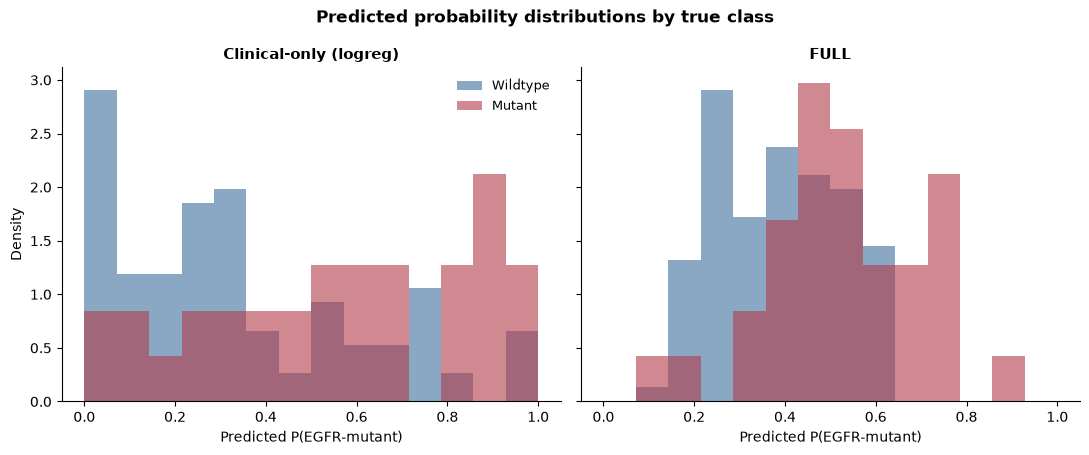

Saved -> figE2_probability_distributions.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
dist_models = [("clinical_logreg", "Clinical-only (logreg)"), ("full_deep", "FULL")]
colors = {"Wildtype": "#3C6E9E", "Mutant": "#B23A48"}

for ax, (col, title) in zip(axes, dist_models):
    for lab, name in [(0, "Wildtype"), (1, "Mutant")]:
        vals = oof_df.loc[y == lab, col].values
        ax.hist(vals, bins=14, range=(0, 1), alpha=0.6, color=colors[name], label=name, density=True)
    ax.set_title(title, fontsize=11, weight="bold")
    ax.set_xlabel("Predicted P(EGFR-mutant)", fontsize=10)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].legend(fontsize=9, frameon=False)
plt.suptitle("Predicted probability distributions by true class", fontsize=12.5, weight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "figE2_probability_distributions.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> figE2_probability_distributions.png")


## 14. Figure E3 — Per-site performance breakdown

**Important caveat:** this is *not* external validation. These out-of-fold predictions came from
models whose training folds could include patients from both sites (folds were stratified jointly
on label and site, not split by site) — see Methods §2.7 in the paper. This figure only checks
whether performance is reasonably consistent across the two constituent cohorts within that
mixed-training setup, which is a much weaker claim than genuine cross-site generalisation
(Table 2's "Leave-one-cohort-out... not performed" limitation still stands).


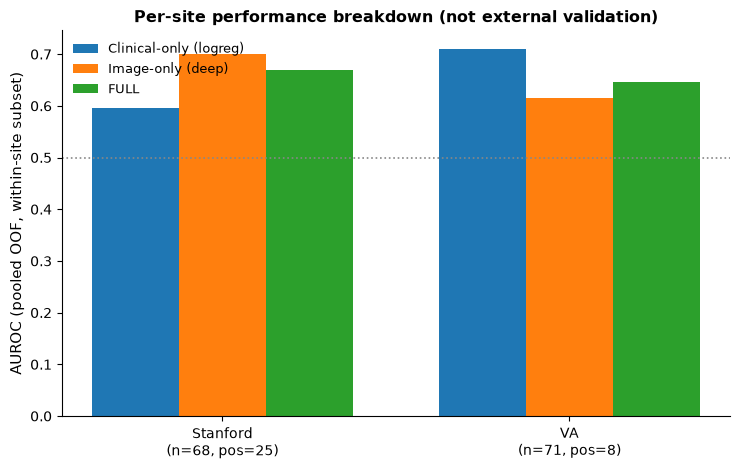

Saved -> figE3_per_site_breakdown.png
Stanford: Clinical-only (logreg)=0.596, Image-only (deep)=0.700, FULL=0.670
VA: Clinical-only (logreg)=0.710, Image-only (deep)=0.615, FULL=0.647


In [14]:
sites = sorted(oof_df["site"].unique())
models_for_site = [
    ("clinical_logreg", "Clinical-only (logreg)"),
    ("image_deep", "Image-only (deep)"),
    ("full_deep", "FULL"),
]

site_aucs = {name: [] for _, name in models_for_site}
for s in sites:
    mask = oof_df["site"] == s
    for col, name in models_for_site:
        try:
            auc = roc_auc_score(y[mask], oof_df.loc[mask, col].values)
        except ValueError:
            auc = np.nan
        site_aucs[name].append(auc)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
x = np.arange(len(sites)); width = 0.25
for i, (_, name) in enumerate(models_for_site):
    ax.bar(x + i*width, site_aucs[name], width=width, label=name)
ax.set_xticks(x + width)
ax.set_xticklabels([f"{s}\n(n={int((oof_df['site']==s).sum())}, pos={int(y[oof_df['site']==s].sum())})" for s in sites])
ax.axhline(0.5, color="#888888", linestyle=":", linewidth=1.2)
ax.set_ylabel("AUROC (pooled OOF, within-site subset)", fontsize=10.5)
ax.set_title("Per-site performance breakdown (not external validation)", fontsize=11.5, weight="bold")
ax.legend(fontsize=9, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "figE3_per_site_breakdown.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> figE3_per_site_breakdown.png")
for idx, s in enumerate(sites):
    line = ", ".join(f"{name}={site_aucs[name][idx]:.3f}" for _, name in models_for_site)
    print(f"{s}: {line}")


## 15. Figure E4 — Clinical-only vs. FULL prediction correlation

Directly tests the paper's central interpretive claim (Discussion §4): if CT imaging's signal
substantially overlaps with what the clinical variables already capture, the two models'
per-patient predictions should be strongly correlated even though they only share the clinical
branch's information indirectly (FULL also has image+radiomics branches).


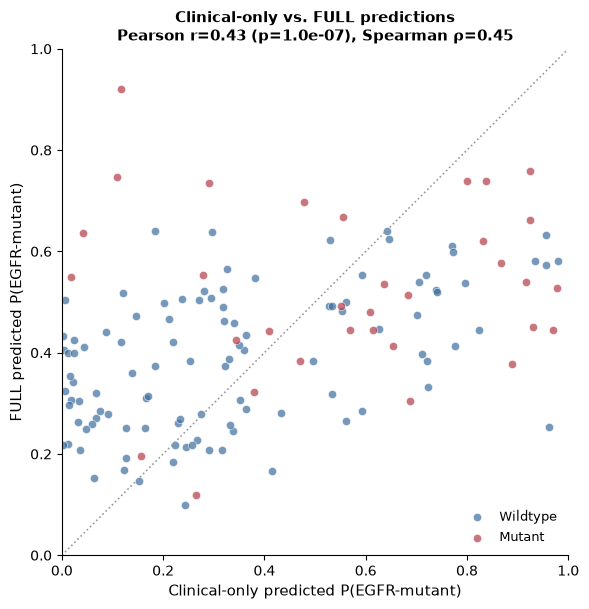

Pearson r = 0.433 (p=1.04e-07)
Spearman rho = 0.450 (p=2.73e-08)
Saved -> figE4_prediction_correlation.png


In [15]:
from scipy.stats import pearsonr, spearmanr

x_pred = oof_df["clinical_logreg"].values
y_pred = oof_df["full_deep"].values
r_pearson, p_pearson = pearsonr(x_pred, y_pred)
r_spearman, p_spearman = spearmanr(x_pred, y_pred)

fig, ax = plt.subplots(figsize=(6.2, 6.2))
for lab, name, color in [(0, "Wildtype", "#3C6E9E"), (1, "Mutant", "#B23A48")]:
    mask = y == lab
    ax.scatter(x_pred[mask], y_pred[mask], color=color, alpha=0.7, s=35, edgecolor="white", linewidth=0.5, label=name)

lims = [0, 1]
ax.plot(lims, lims, color="#999999", linestyle=":", linewidth=1.2)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Clinical-only predicted P(EGFR-mutant)", fontsize=10.5)
ax.set_ylabel("FULL predicted P(EGFR-mutant)", fontsize=10.5)
ax.set_title(f"Clinical-only vs. FULL predictions\nPearson r={r_pearson:.2f} (p={p_pearson:.1e}), Spearman \u03c1={r_spearman:.2f}",
             fontsize=11, weight="bold")
ax.legend(fontsize=9, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / "figE4_prediction_correlation.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Pearson r = {r_pearson:.3f} (p={p_pearson:.2e})")
print(f"Spearman rho = {r_spearman:.3f} (p={p_spearman:.2e})")
print("Saved -> figE4_prediction_correlation.png")


## 16. Figure E5 — Top clinical feature importances

An instant logistic regression fit on all 139 patients (not a CV model — purely descriptive/
interpretability, fit in milliseconds, not part of the reported ablation results). Coefficients are
on standardised features, so magnitude is comparable across features.


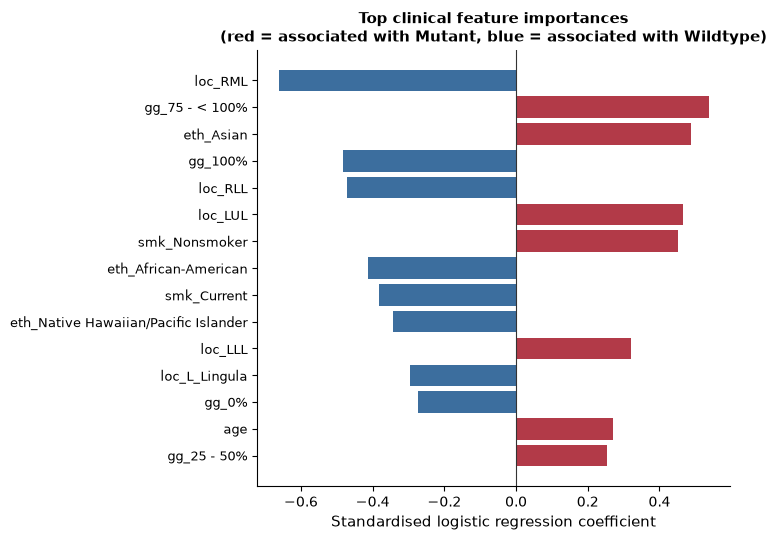

Saved -> figE5_clinical_feature_importance.png


In [16]:
tab_cols = build_tabular(cohort).columns.tolist()
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
clf.fit(tab_mat, y)
coefs = clf.named_steps["logisticregression"].coef_.ravel()

order = np.argsort(np.abs(coefs))[::-1][:15]
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors_imp = ["#B23A48" if coefs[i] > 0 else "#3C6E9E" for i in order]
ax.barh(range(len(order)), coefs[order][::-1], color=colors_imp[::-1])
ax.set_yticks(range(len(order)))
ax.set_yticklabels([tab_cols[i] for i in order][::-1], fontsize=9)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("Standardised logistic regression coefficient", fontsize=10.5)
ax.set_title("Top clinical feature importances\n(red = associated with Mutant, blue = associated with Wildtype)",
             fontsize=11, weight="bold")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "figE5_clinical_feature_importance.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> figE5_clinical_feature_importance.png")


## 17. Figure E6 — Top radiomics feature importances

Same approach, on the 27 radiomics features. If no feature stands out with a large coefficient,
that supports the paper's finding that radiomics carries comparatively weak, diffuse signal in
this cohort rather than a few strong discriminative features.


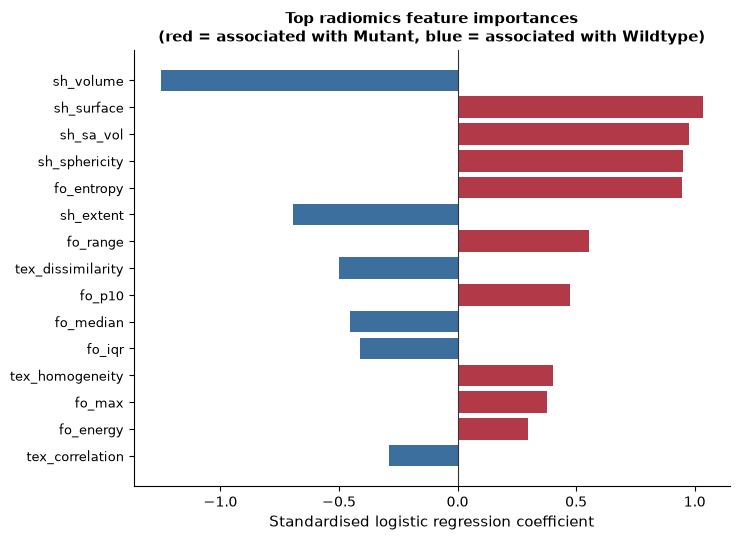

Saved -> figE6_radiomics_feature_importance.png


In [17]:
rad_cols = ["fo_mean","fo_std","fo_median","fo_p10","fo_p90","fo_iqr","fo_min","fo_max","fo_range",
            "fo_mad","fo_skew","fo_kurt","fo_energy","fo_entropy","fo_uniformity",
            "sh_volume","sh_extent","sh_elongation","sh_surface","sh_sa_vol","sh_sphericity",
            "tex_contrast","tex_dissimilarity","tex_homogeneity","tex_energy","tex_correlation","tex_ASM"]
assert len(rad_cols) == rad_mat_raw.shape[1], "radiomics column list doesn't match rad_mat_raw width - check Section 8"

clf_r = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
clf_r.fit(rad_mat_raw, y)
coefs_r = clf_r.named_steps["logisticregression"].coef_.ravel()

order_r = np.argsort(np.abs(coefs_r))[::-1][:15]
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors_r = ["#B23A48" if coefs_r[i] > 0 else "#3C6E9E" for i in order_r]
ax.barh(range(len(order_r)), coefs_r[order_r][::-1], color=colors_r[::-1])
ax.set_yticks(range(len(order_r)))
ax.set_yticklabels([rad_cols[i] for i in order_r][::-1], fontsize=9)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("Standardised logistic regression coefficient", fontsize=10.5)
ax.set_title("Top radiomics feature importances\n(red = associated with Mutant, blue = associated with Wildtype)",
             fontsize=11, weight="bold")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "figE6_radiomics_feature_importance.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> figE6_radiomics_feature_importance.png")


## 18. Load the saved FULL model checkpoint (inference only, no training)

Loads `egfr_out/egfr_fusion_v32.pt` — the exact checkpoint saved by the original notebook's
Section 15 (`torch.save(final_model.state_dict(), OUTPUT_DIR/"egfr_fusion_v32.pt")`). We rebuild the
same global (non-per-fold) radiomics standardisation that Section 15 used before saving, so the
loaded weights see inputs in the same distribution they were trained on. This is a forward pass
only — `.eval()` mode, `torch.no_grad()`, no gradient updates, no training loop.


In [18]:
CHECKPOINT_PATH = OUTPUT_DIR / "egfr_fusion_v32.pt"
assert CHECKPOINT_PATH.exists(), (
    f"{CHECKPOINT_PATH} not found. Check egfr_out/ for the exact checkpoint filename "
    "(e.g. egfr_fusion_v33.pt, egfr_fusion_v35.pt) and update CHECKPOINT_PATH above."
)

# Same global (all-patient) StandardScaler Section 15 used before saving this checkpoint -
# NOT the per-fold scaler used during cross-validation.
RAD_MAT_GLOBAL = np.nan_to_num(StandardScaler().fit_transform(rad_mat_raw)).astype(np.float32)

full_model = FusionNet(N_TAB, N_RAD, True, True, True).to(DEVICE)
state_dict = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
full_model.load_state_dict(state_dict)
full_model.eval()
print(f"Loaded checkpoint: {CHECKPOINT_PATH.name}")
print(f"Trainable params: {sum(p.numel() for p in full_model.parameters()):,}")


Loaded checkpoint: egfr_fusion_v32.pt
Trainable params: 11,225,281


## 19. Figure E7 — PCA of the FULL model's learned fused embeddings

Runs every patient's cube/clinical/radiomics data through the loaded model's three encoders
(`model.img`, `model.tab`, `model.rad` — the same submodules `forward()` calls internally) and
concatenates them into the 128-dimensional fused vector the fusion head actually sees, **before**
the final classification layer. Projecting this to 2D with PCA shows whether the model has learned
a representation that separates Mutant from Wildtype — or whether the two classes sit on top of
each other in the space the model actually uses to make its decision.


Embeddings shape: (139, 128) (expect: N patients x 128)
Explained variance ratio: PC1=76.46%, PC2=18.66%


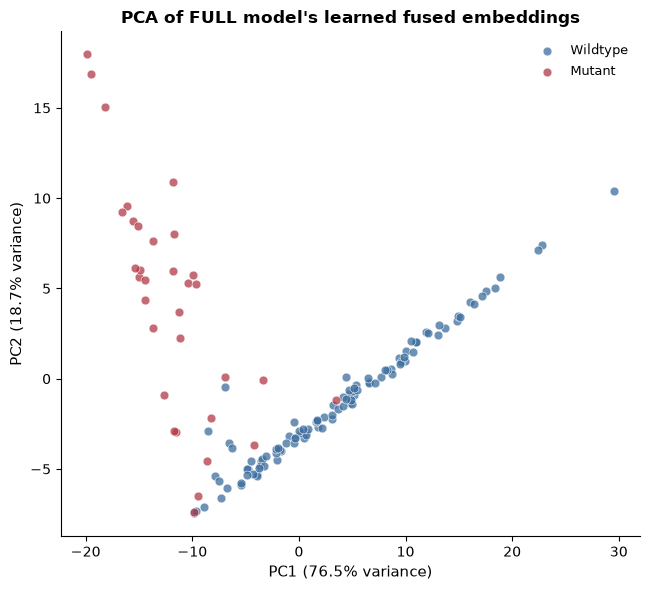

Saved -> figE7_embedding_pca.png


In [19]:
@torch.no_grad()
def get_fused_embeddings(model, indices):
    loader = DataLoader(EGFRDataset(indices), batch_size=BATCH_SIZE)
    embeds = []
    for img, tab, rad, _ in loader:
        img, tab, rad = img.to(DEVICE), tab.to(DEVICE), rad.to(DEVICE)
        f_img = model.img(img)
        f_tab = model.tab(tab)
        f_rad = model.rad(rad)
        embeds.append(torch.cat([f_img, f_tab, f_rad], dim=1).float().cpu().numpy())
    return np.concatenate(embeds, axis=0)

# temporarily swap in the global radiomics standardisation this checkpoint expects
_rad_mat_backup = RAD_MAT.copy() if "RAD_MAT" in dir() else None
RAD_MAT = RAD_MAT_GLOBAL

all_idx = np.arange(len(cohort))
embeddings = get_fused_embeddings(full_model, all_idx)
print("Embeddings shape:", embeddings.shape, "(expect: N patients x 128)")

pca = PCA(n_components=2, random_state=0)
emb_2d = pca.fit_transform(embeddings)
print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

fig, ax = plt.subplots(figsize=(6.6, 6))
for lab, name, color in [(0, "Wildtype", "#3C6E9E"), (1, "Mutant", "#B23A48")]:
    mask = labels.astype(int) == lab
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], color=color, alpha=0.75, s=40,
               edgecolor="white", linewidth=0.5, label=name)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=10.5)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=10.5)
ax.set_title("PCA of FULL model's learned fused embeddings", fontsize=12, weight="bold")
ax.legend(fontsize=9.5, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "figE7_embedding_pca.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> figE7_embedding_pca.png")


## 20. Summary


In [20]:
print("New figures saved this session:")
for f in sorted(FIG_DIR.glob("figE*.png")):
    print(" ", f.name)


New figures saved this session:
  figE1_precision_recall.png
  figE2_probability_distributions.png
  figE3_per_site_breakdown.png
  figE4_prediction_correlation.png
  figE5_clinical_feature_importance.png
  figE6_radiomics_feature_importance.png
  figE7_embedding_pca.png
